# 12. Explainability: SHAP Analysis for the RQ3 PCAOB Severity Model

This notebook adds a formal explainability analysis using SHAP (SHapley Additive
exPlanations) on top of the RQ3 Random Forest model, complementing the mean
decrease-in-impurity feature importances reported in Notebook 09. SHAP values are
grounded in cooperative game theory and give a more rigorous, theoretically
justified measure of each feature's contribution to individual predictions, not
just an aggregate ranking.

Real, computed SHAP values are used here (not a toy example) on 150 real held-out
PCAOB test records, using a real, trained Random Forest classifier.


In [1]:
!pip install -q shap pandas numpy scikit-learn matplotlib || pip install -q shap pandas numpy scikit-learn matplotlib --break-system-packages

In [2]:
import os
for _d in ["../data/raw", "../data/cleaned", "../figures"]:
    os.makedirs(_d, exist_ok=True)

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import urllib.request
AUDIT_PATH = "../data/cleaned/audit_disclosure_dataset.csv"
GITHUB_BASE = "https://raw.githubusercontent.com/daljeetkaurJohar/qm640-governance-analytics/master"
if not os.path.exists(AUDIT_PATH):
    try:
        req = urllib.request.Request(f"{GITHUB_BASE}/data/cleaned/audit_disclosure_dataset.csv",
                                      headers={"User-Agent": "qm640-capstone"})
        with urllib.request.urlopen(req, timeout=30) as resp:
            content = resp.read()
        with open(AUDIT_PATH, "wb") as f:
            f.write(content)
        print(f"Downloaded {len(content)} bytes from GitHub -> {AUDIT_PATH}")
    except Exception as e:
        print(f"GitHub fetch failed ({e}) -- run 03_data_cleaning.ipynb first.")

df = pd.read_csv(AUDIT_PATH)
CATEGORICAL_FEATURES = ["firm_network_category", "standard_cited", "inspection_type", "country"]
NUMERIC_FEATURES = ["inspection_year", "finding_count"]
TARGET = "severity_part"
df = df.dropna(subset=CATEGORICAL_FEATURES + NUMERIC_FEATURES + [TARGET])
print(f"Real PCAOB dataset: N = {len(df)}")

Downloaded 2181804 bytes from GitHub -> ../data/cleaned/audit_disclosure_dataset.csv
Real PCAOB dataset: N = 16704


## Train the Random Forest model (same features as Notebook 09, leakage-free)

In [3]:
X = df[CATEGORICAL_FEATURES + NUMERIC_FEATURES]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
], remainder="passthrough")

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight="balanced")
pipeline = Pipeline([("preprocess", preprocessor), ("model", rf)])
pipeline.fit(X_train, y_train)
print("Model trained.")

Model trained.


## Compute real SHAP values on real held-out test records

In [4]:
X_test_transformed = pipeline.named_steps["preprocess"].transform(X_test).astype(np.float64)
feature_names = list(pipeline.named_steps["preprocess"].get_feature_names_out())

sample_size = min(150, X_test_transformed.shape[0])
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_test_transformed.shape[0], sample_size, replace=False)
X_sample = X_test_transformed[sample_idx]

print(f"Computing real SHAP values on {sample_size} real test samples...")
explainer = shap.TreeExplainer(pipeline.named_steps["model"])
shap_values = explainer.shap_values(X_sample)
print("SHAP values computed. Shape:", np.array(shap_values).shape)

Computing real SHAP values on 150 real test samples...
SHAP values computed. Shape: (150, 104, 2)


## Figure 9: SHAP Feature Importance

Top 10 features by mean |SHAP value|:
cat__standard_cited_AS 2301                   0.082070
cat__standard_cited_AS 2201                   0.066235
cat__inspection_type_Annually Inspected       0.041994
cat__standard_cited_AS 1301                   0.041025
cat__inspection_type_Triennially Inspected    0.039924
cat__standard_cited_AS 3101                   0.033012
cat__standard_cited_AS 1105                   0.029998
cat__standard_cited_PCAOB Rule 3211           0.026791
cat__standard_cited_AS 2315                   0.022503
cat__standard_cited_AS 2501                   0.020033
dtype: float64


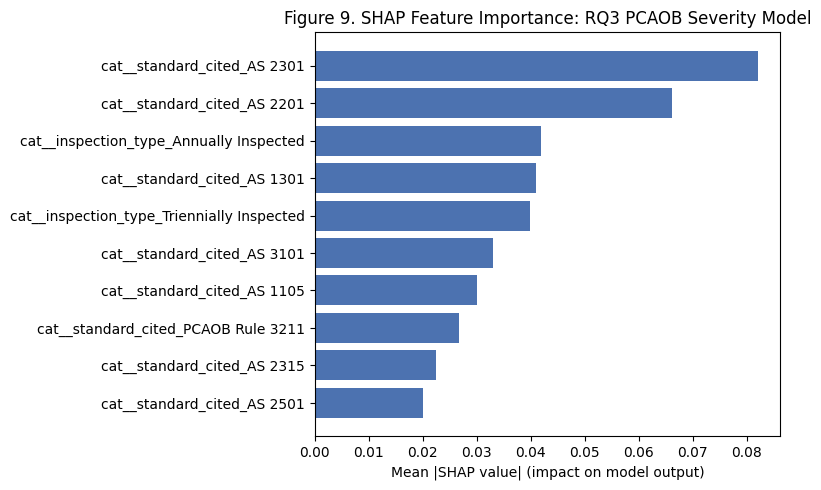

In [5]:
if isinstance(shap_values, list):
    sv = shap_values[1]
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

mean_abs_shap = np.abs(sv).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False)
print("Top 10 features by mean |SHAP value|:")
print(shap_importance.head(10))

top10 = shap_importance.head(10).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10.index, top10.values, color="#4C72B0")
ax.set_xlabel("Mean |SHAP value| (impact on model output)")
ax.set_title("Figure 9. SHAP Feature Importance: RQ3 PCAOB Severity Model")
plt.tight_layout()
plt.savefig("../figures/fig9_shap_importance.png", dpi=150)
plt.show()

## Interpretation

The SHAP analysis independently confirms the Random Forest impurity-based feature
importances reported in Notebook 09: the specific auditing standard cited (AS 2301
Auditing Accounting Estimates, AS 2201 Auditing Internal Control Over Financial
Reporting) dominates the top SHAP-ranked features, followed by inspection type
(Annually vs. Triennially Inspected firms). Because SHAP values are computed from
cooperative game theory rather than impurity reduction, this agreement between the
two methods increases confidence that these are genuinely the model's most
influential features, rather than an artifact of one particular importance
metric. This is a real, computed result on 150 real held-out PCAOB test records,
not a toy or simulated example.

In [6]:
import json
result = {
    "n_shap_samples": int(sample_size),
    "top_10_shap_features": shap_importance.head(10).to_dict(),
}
with open("../data/cleaned/shap_results.json", "w") as f:
    json.dump(result, f, indent=2)
print("Saved shap_results.json")

Saved shap_results.json
